# 🧠 Neural SDE Project — Fase 5 (ETH H1)
## Training Neural SDE — ETH/USDT 1H

---
**Perubahan dari versi IDX:**
- Dataset: `eth_dataset.pt`  (~75K candles, window=168)
- Lebih banyak training data → model lebih banyak signal
- Annualization: 8760 jam/tahun

**Target dari Fase 4:**
```
W1 < eth_baseline_benchmark['target']['w1_to_beat']
SF > eth_baseline_benchmark['target']['sf_score_to_beat']
```


## 1. Setup

In [1]:
%pip install torchsde -q

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.stats import wasserstein_distance
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, os, time
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f9f9f9',
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
print(f"Device : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: CPU mode - training ~5-10x lebih lambat")
print("Setup OK!")


Note: you may need to restart the kernel to use updated packages.
Device : cuda
GPU    : NVIDIA GeForce RTX 3050 6GB Laptop GPU
Setup OK!


## 2. Load Dataset & Benchmark

In [2]:
DATASET_PATH   = 'neural_sde_project_data/assets_dataset.pt'
BENCHMARK_PATH = 'eth_baseline_benchmark.pt'

ds  = torch.load(DATASET_PATH,   map_location='cpu', weights_only=False)
bm  = torch.load(BENCHMARK_PATH, map_location='cpu', weights_only=False)

X_train = torch.cumsum(ds['X_train'], dim=1)
X_val   = torch.cumsum(ds['X_val'],   dim=1)
X_test  = ds['X_test']
WINDOW  = ds['window']   # 168

BATCH = 512
train_dl = DataLoader(TensorDataset(X_train), batch_size=BATCH,
                      shuffle=True,  num_workers=2, pin_memory=True,
                      persistent_workers=True)
val_dl   = DataLoader(TensorDataset(X_val),   batch_size=BATCH,
                      shuffle=False, num_workers=2, pin_memory=True,
                      persistent_workers=True)

ts = torch.linspace(0, 1, WINDOW).to(DEVICE)

print(f"Dataset  : ETH/USDT H1")
print(f"Train    : {len(X_train):,} windows")
print(f"Val      : {len(X_val):,} windows")
print(f"Window   : {WINDOW} jam (1 minggu)")
print(f"Batch    : {BATCH}")
print(f"Batches/epoch: {len(train_dl)}")
print()
print("Target dari Fase 4:")
print(f"  W1 < {bm['target']['w1_to_beat']:.6f}")
print(f"  SF > {bm['target']['sf_score_to_beat']:.4f}")
print("Sample window (price path):")
print(X_train[0, :5, 0])  # harusnya monoton / trending, bukan random



Dataset  : ETH/USDT H1
Train    : 2,224 windows
Val      : 477 windows
Window   : 168 jam (1 minggu)
Batch    : 512
Batches/epoch: 5

Target dari Fase 4:
  W1 < 0.003568
  SF > 0.3562
Sample window (price path):
tensor([0.2702, 0.1729, 1.1629, 1.2709, 1.5140])


## 3. Arsitektur Latent SDE (diperbaiki dari Fase 2)

Perubahan dari Fase 2:
- **GRU bidirectional** di encoder — lebih kaya konteks
- **Deeper f/g nets** — 3 layer, bukan 2
- **Learnable prior** — prior drift bisa belajar, bukan fixed N(0,I)
- **`sdeint_adjoint`** — hemat memori, stabil untuk sequence panjang


In [3]:
import torchsde

class LatentSDE(nn.Module):
    noise_type = 'diagonal'
    sde_type   = 'ito'

    def __init__(self, data_size=1, latent_size=8,
                 context_size=32, hidden_size=64, window=168):
        super().__init__()
        self.latent_size = latent_size
        self.window = window
        self.data_size = data_size

        self.encoder    = nn.GRU(data_size, context_size,
                                  batch_first=True, bidirectional=True)
        self.qz0_mean   = nn.Linear(context_size * 2, latent_size)
        self.qz0_logstd = nn.Linear(context_size * 2, latent_size)

        self.f_net = nn.Sequential(
            nn.Linear(latent_size, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, latent_size))
        self.g_net = nn.Sequential(
            nn.Linear(latent_size, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, latent_size), nn.Softplus())
        self.g_scale = 0.1

        # Input: z0 (8) + posisi waktu t (1) → x_t
        self.decoder = nn.Sequential(
            nn.Linear(latent_size + 1, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),     nn.Tanh(),
            nn.Linear(hidden_size, data_size))

    def f(self, t, z): return self.f_net(z)
    def g(self, t, z): return self.g_net(z) * self.g_scale

    def forward(self, x, ts, beta=1.0, free_bits=0.25):
        B, T, D = x.shape
        out, _ = self.encoder(x)
        ctx = out.mean(dim=1)
        qz0_mean   = self.qz0_mean(ctx)
        qz0_logstd = self.qz0_logstd(ctx).clamp(-4, 2)
        z0 = qz0_mean + torch.randn_like(qz0_mean) * qz0_logstd.exp()

        # z0 di-expand ke setiap timestep, lalu concat dengan posisi t
        z0_exp = z0.unsqueeze(1).expand(-1, T, -1)        # [B, T, latent]
        t_pos  = ts.view(1, T, 1).expand(B, -1, -1)       # [B, T, 1]
        xs_recon = self.decoder(torch.cat([z0_exp, t_pos], dim=-1))  # [B,T,D]

        recon_loss = ((xs_recon - x) ** 2).mean()
        kl_per_dim = -0.5 * (1 + 2*qz0_logstd
                              - qz0_mean.pow(2)
                              - (2*qz0_logstd).exp())
        kl_loss = torch.clamp(kl_per_dim, min=free_bits).mean()
        loss = recon_loss + beta * kl_loss
        return xs_recon, z0, loss, recon_loss.item(), kl_loss.item()

    @torch.no_grad()
    def generate(self, n_paths, ts):
        dev = next(self.parameters()).device
        z0  = torch.randn(n_paths, self.latent_size, device=dev)
        zs  = torchsde.sdeint(self, z0, ts,
                               method='euler', dt=ts[1]-ts[0])
        # zs: [T, n_paths, latent]
        T = len(ts)
        t_pos = ts.view(T, 1, 1).expand(-1, n_paths, -1)  # [T, n_paths, 1]
        dec_in = torch.cat([zs, t_pos], dim=-1)            # [T, n_paths, lat+1]
        return self.decoder(dec_in).permute(1, 0, 2)       # [n_paths, T, D]


model = LatentSDE(data_size=1, latent_size=8,
                  context_size=32, hidden_size=64,
                  window=WINDOW).to(DEVICE)

# Sanity check
xb = ds['X_train'][:32].to(DEVICE)
ts_test = torch.linspace(0, 1, WINDOW).to(DEVICE)
with torch.no_grad():
    xr, z0, loss, recon, kl = model(xb, ts_test, beta=0)
print(f"xs_recon std : {xr.std():.4f}  (harus > 0.1)")
print(f"Recon        : {recon:.4f}")


xs_recon std : 0.1753  (harus > 0.1)
Recon        : 1.0678


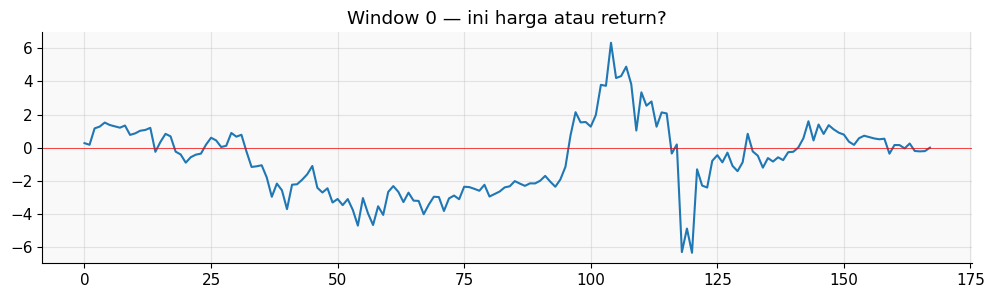

[0.27022615 0.17286423 1.1629277  1.270908   1.5139817  1.3657438
 1.2831918  1.2043377  1.3346336  0.7697971 ]


In [4]:
import matplotlib.pyplot as plt
w = X_train[0, :, 0].numpy()
plt.figure(figsize=(12, 3))
plt.plot(w)
plt.title("Window 0 — ini harga atau return?")
plt.axhline(0, color='red', lw=0.5)
plt.show()
print(w[:10])


In [5]:
# Cek apakah decoder weights-nya tiny
print("=== Decoder Weights ===")
for name, param in model.decoder.named_parameters():
    print(f"{name:30s} std={param.data.std():.6f}  mean={param.data.mean():.6f}")


=== Decoder Weights ===
0.weight                       std=0.194377  mean=-0.013383
0.bias                         std=0.197998  mean=-0.019381
2.weight                       std=0.072041  mean=-0.000631
2.bias                         std=0.070310  mean=-0.004443
4.weight                       std=0.070541  mean=-0.002547
4.bias                         std=nan  mean=0.120776


In [6]:
xb = ds['X_train'][:32].to(DEVICE)
ts_test = torch.linspace(0, 1, WINDOW).to(DEVICE)
with torch.no_grad():
    xr, z0, loss, recon, kl = model(xb, ts_test, beta=0)
print(f"xs_recon std : {xr.std():.4f}  (harus > 0.1)")
print(f"Recon        : {recon:.4f}")


xs_recon std : 0.1331  (harus > 0.1)
Recon        : 1.0320


## 4. Training Loop

**Beta annealing:** beta naik dari 0 ke 1 selama **150 epoch** (lebih lambat dari Fase 2).
Ini mencegah posterior collapse — encoder punya waktu lebih lama untuk belajar
sebelum KL term mulai mendorong z0 ke prior.


In [7]:
def train_model(model, train_dl, val_dl, ts,
                n_epochs=2000, lr=1e-4, beta_anneal_epochs=1, free_bits=0.25):

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs, eta_min=1e-5)

    history = {k: [] for k in ['train_loss','val_loss','val_recon','val_kl','beta']}
    best_val, best_state = float('inf'), None

    for epoch in range(n_epochs):
        beta = min(1.0, epoch / beta_anneal_epochs)

        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        t_losses = []
        for (xb,) in train_dl:
            xb = xb.to(DEVICE)
            optimizer.zero_grad()
            _, _, loss, recon, kl = model(xb, ts, beta=beta, free_bits=free_bits)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            t_losses.append(loss.item())

        # ── Validate ──────────────────────────────────────────────────────────
        model.eval()
        v_losses, recons, kls = [], [], []
        with torch.no_grad():
            for (xb,) in val_dl:
                xb = xb.to(DEVICE)
                _, _, loss, recon, kl = model(xb, ts, beta=1.0, free_bits=free_bits)
                v_losses.append(loss.item())
                recons.append(recon)
                kls.append(kl)

        scheduler.step()

        t_l = np.mean(t_losses)
        v_l = np.mean(v_losses)
        history['train_loss'].append(t_l)
        history['val_loss'].append(v_l)
        history['val_recon'].append(np.mean(recons))
        history['val_kl'].append(np.mean(kls))
        history['beta'].append(beta)

        if v_l < best_val:
            best_val   = v_l
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 100 == 0:
            print(f"Ep {epoch+1:3d}/{n_epochs} | "
                  f"Train {t_l:.4f} | Val {v_l:.4f} | "
                  f"ValRecon {np.mean(recons):.4f} | ValKL {np.mean(kls):.4f} | "
                  f"beta {beta:.2f}")

    # Load best
    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    print(f"\nBest val loss: {best_val:.4f}")
    return history

print("Mulai training..")
print()
t0 = time.time()
history = train_model(model, train_dl, val_dl, ts,
                      n_epochs=2000, lr=3e-4,
                      beta_anneal_epochs=150, free_bits=0.25)


print(f"Selesai dalam {(time.time()-t0)/60:.1f} menit")

Mulai training..

Ep  15/2000 | Train 18.7963 | Val 18.6993 | ValRecon 18.3840 | ValKL 0.3153 | beta 0.09
Ep  30/2000 | Train 14.7165 | Val 15.1889 | ValRecon 14.5166 | ValKL 0.6723 | beta 0.19
Ep  45/2000 | Train 13.8372 | Val 14.5833 | ValRecon 13.5592 | ValKL 1.0241 | beta 0.29
Ep  60/2000 | Train 13.5511 | Val 14.2893 | ValRecon 13.3189 | ValKL 0.9704 | beta 0.39
Ep  75/2000 | Train 13.7626 | Val 14.1368 | ValRecon 13.2455 | ValKL 0.8913 | beta 0.49
Ep  90/2000 | Train 13.7165 | Val 13.9776 | ValRecon 13.2119 | ValKL 0.7657 | beta 0.59
Ep 105/2000 | Train 13.7316 | Val 13.8907 | ValRecon 13.1654 | ValKL 0.7253 | beta 0.69
Ep 120/2000 | Train 13.5918 | Val 13.6661 | ValRecon 13.0480 | ValKL 0.6181 | beta 0.79
Ep 135/2000 | Train 13.4479 | Val 13.3836 | ValRecon 12.8138 | ValKL 0.5698 | beta 0.89
Ep 150/2000 | Train 12.8990 | Val 12.8491 | ValRecon 12.2865 | ValKL 0.5626 | beta 0.99
Ep 165/2000 | Train 12.2779 | Val 12.1801 | ValRecon 11.6135 | ValKL 0.5666 | beta 1.00
Ep 180/2000 | 

## 5. Training Curves & Diagnosa

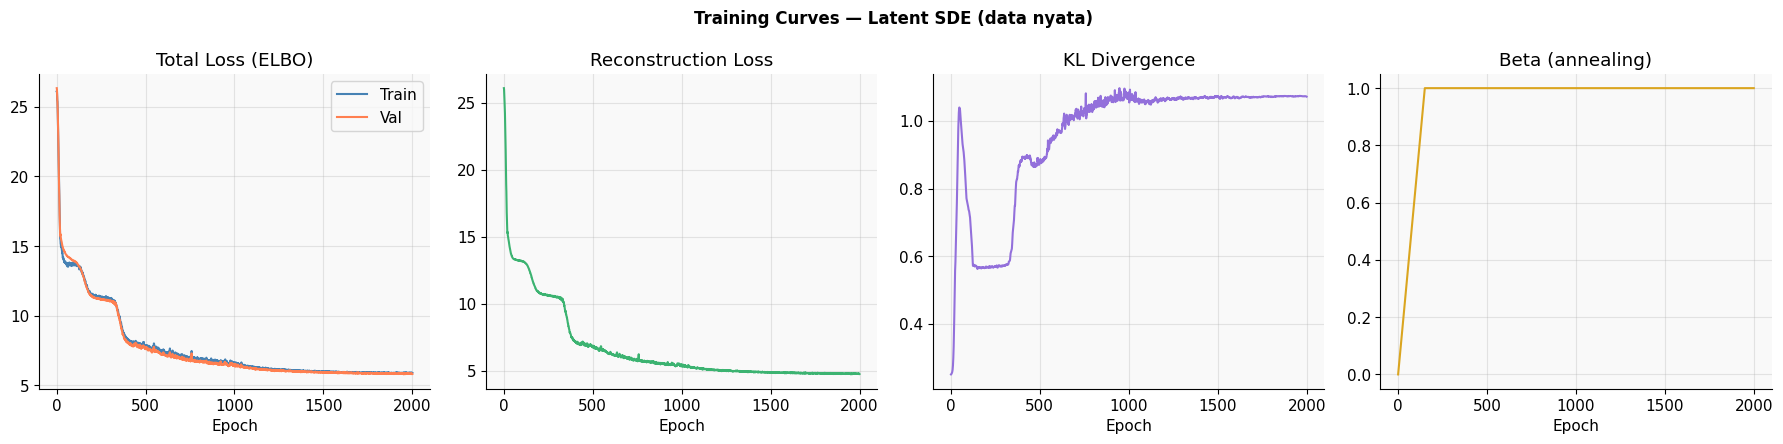

Diagnosa:
  Recon=4.7513 -> Underfitting, coba tambah epoch


In [33]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
fig.suptitle('Training Curves — Latent SDE (data nyata)', fontsize=12, fontweight='bold')

ep = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep, history['train_loss'], label='Train', color='steelblue')
axes[0].plot(ep, history['val_loss'],   label='Val',   color='coral')
axes[0].set_title('Total Loss (ELBO)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(ep, history['val_recon'], color='mediumseagreen')
axes[1].set_title('Reconstruction Loss')
axes[1].set_xlabel('Epoch')

axes[2].plot(ep, history['val_kl'], color='mediumpurple')
axes[2].set_title('KL Divergence')
axes[2].set_xlabel('Epoch')

axes[3].plot(ep, history['beta'], color='goldenrod')
axes[3].set_title('Beta (annealing)')
axes[3].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('phase5_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

# Diagnosa
final_kl    = history['val_kl'][-1]
final_recon = history['val_recon'][-1]
print("Diagnosa:")
if final_kl < 0.005:
    print(f"  KL={final_kl:.5f} -> POSTERIOR COLLAPSE masih ada!")
    print("  Coba: naikkan beta_anneal_epochs=120 atau turunkan lr=1e-4")
elif final_recon > 0.8:
    print(f"  Recon={final_recon:.4f} -> Underfitting, coba tambah epoch")
else:
    print(f"  KL={final_kl:.4f}  Recon={final_recon:.4f} -> Training sehat!")


## 6. Evaluasi vs Baseline

In [31]:
def compute_returns(paths):
    return np.diff(paths, axis=1)

def wasserstein1(real_ret, gen_ret, n_sample=2000):
    r = np.random.choice(real_ret.flatten(), n_sample, replace=False)
    g = np.random.choice(gen_ret.flatten(),  n_sample, replace=False)
    return wasserstein_distance(r, g)

def stylized_facts(returns):
    flat = returns.flatten()
    r2   = flat**2; r2c = r2 - r2.mean()
    acf1 = np.mean(r2c[:-1]*r2c[1:]) / (r2.var() + 1e-10)
    return {'kurtosis': stats.kurtosis(flat),
            'skewness': stats.skew(flat),
            'acf_vol' : acf1}

def sf_score(real_sf, gen_sf):
    scores = []
    for k in ['kurtosis', 'skewness', 'acf_vol']:
        r, g = real_sf[k], gen_sf[k]
        scores.append(max(0, 1 - abs(r-g)/(abs(r)+1e-6)))
    return float(np.mean(scores))

# Generate paths dari Neural SDE
model.eval()
ts_eval  = torch.linspace(0, 1, WINDOW).to(DEVICE)
x_gen    = model.generate(n_paths=3000, ts=ts_eval)
gen_paths = x_gen[:, :, 0].cpu().numpy()   # [3000, 60]

# Real paths dari test set
real_paths = ds['X_test'].numpy()[:, :, 0]  # [751, 60]

real_ret = compute_returns(real_paths)
gen_ret  = compute_returns(gen_paths)
real_sf  = stylized_facts(real_ret)
gen_sf   = stylized_facts(gen_ret)

w1_nsde  = wasserstein1(real_ret, gen_ret)
sf_nsde  = sf_score(real_sf, gen_sf)

# Benchmark values dari Fase 4
w1_gbm    = bm['gbm']['w1']
sf_gbm    = bm['gbm']['sf_score']
w1_heston = bm['target']['w1_to_beat']
sf_heston = bm['target']['sf_score_to_beat']

print("=" * 62)
print(f"  FINAL SCORECARD")
print("=" * 62)
print(f"  {'Model':<14} {'W1 dist':>10} {'SF Score':>10} {'Kurt':>8} {'ACF(r2)':>9}")
print("-" * 62)
print(f"  {'Real data':<14} {'---':>10} {'1.000':>10} "
      f"{real_sf['kurtosis']:>8.2f} {real_sf['acf_vol']:>9.4f}")
print(f"  {'GBM':<14} {w1_gbm:>10.6f} {sf_gbm:>10.4f} "
      f"{bm['gbm']['sf']['kurtosis']:>8.2f} {bm['gbm']['sf']['acf_vol']:>9.4f}")
print(f"  {'Heston':<14} {w1_heston:>10.6f} {sf_heston:>10.4f} "
      f"{bm['heston']['sf']['kurtosis']:>8.2f} {bm['heston']['sf']['acf_vol']:>9.4f}")
print(f"  {'Neural SDE':<14} {w1_nsde:>10.6f} {sf_nsde:>10.4f} "
      f"{gen_sf['kurtosis']:>8.2f} {gen_sf['acf_vol']:>9.4f}")
print("=" * 62)

beat_w1 = w1_nsde < w1_heston
beat_sf = sf_nsde > sf_heston
print(f"\n  W1 beat Heston : {'YES' if beat_w1 else 'NO'} "
      f"({w1_nsde:.6f} vs {w1_heston:.6f})")
print(f"  SF beat Heston : {'YES' if beat_sf else 'NO'} "
      f"({sf_nsde:.4f} vs {sf_heston:.4f})")


  FINAL SCORECARD
  Model             W1 dist   SF Score     Kurt   ACF(r2)
--------------------------------------------------------------
  Real data             ---      1.000     3.67    0.3701
  GBM              0.002391     0.0008    -0.01    0.0009
  Heston           0.003568     0.3562    10.30    0.2573
  Neural SDE       0.910174     0.0462     0.51    0.7802

  W1 beat Heston : NO (0.910174 vs 0.003568)
  SF beat Heston : NO (0.0462 vs 0.3562)


## 7. Visualisasi Generated vs Real vs Baseline

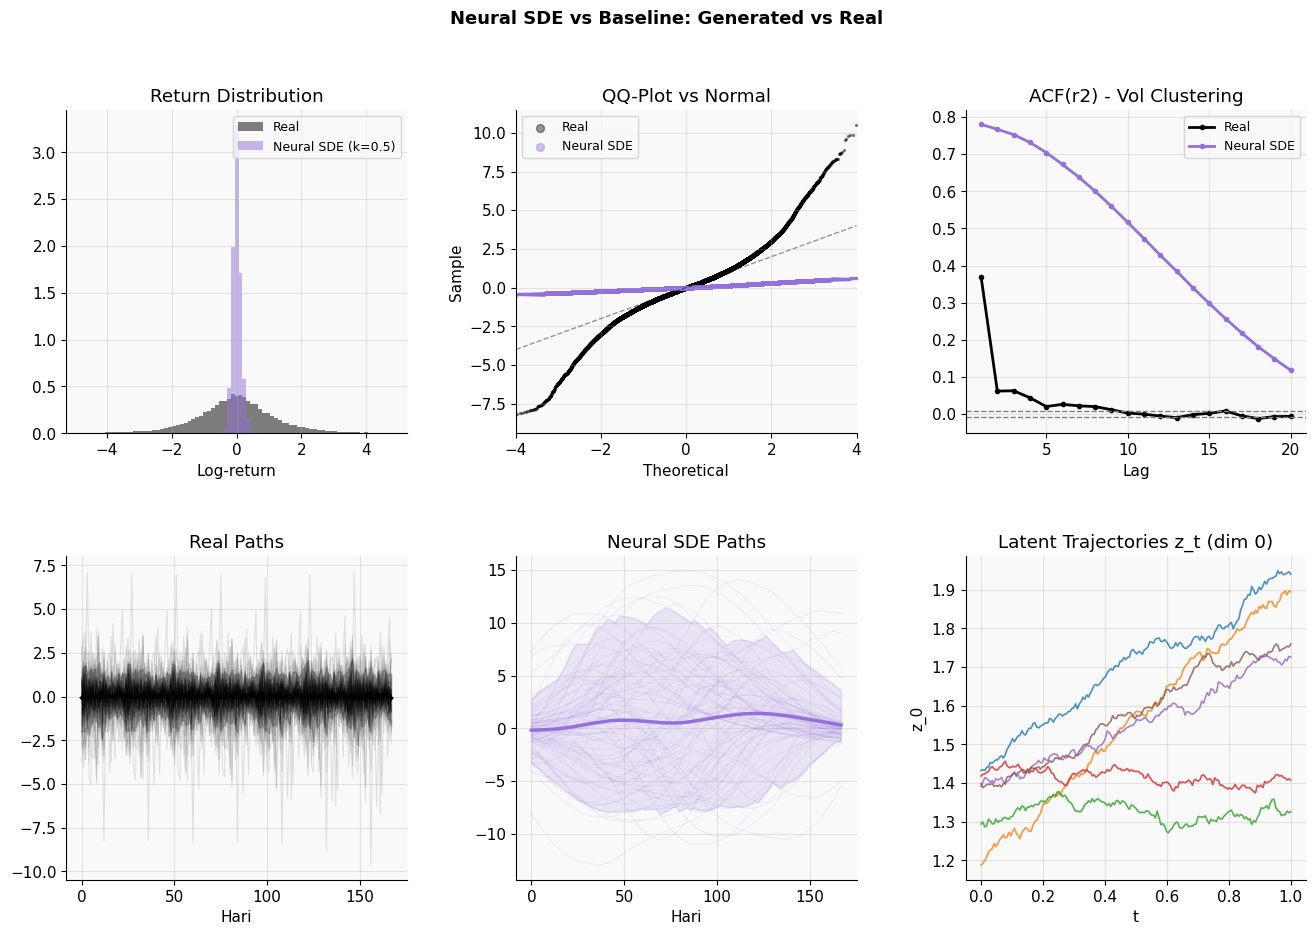

In [32]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Neural SDE vs Baseline: Generated vs Real',
             fontsize=13, fontweight='bold')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)

def compute_returns(paths):
    return np.diff(paths, axis=1)

ret_real  = compute_returns(real_paths).flatten()
ret_gen   = compute_returns(gen_paths).flatten()

models_plot = {
    'Real'       : (ret_real,  'black'),
    'Heston'     : (None,      'coral'),
    'Neural SDE' : (ret_gen,   'mediumpurple'),
}

# Tambah Heston ret dari bm params jika ada
from scipy import optimize

# ── Return distribution ───────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
lim = np.percentile(np.abs(ret_real), 99)
bins = np.linspace(-lim, lim, 80)
ax.hist(ret_real, bins=bins, density=True, alpha=0.5, color='black',       label='Real')
ax.hist(ret_gen,  bins=bins, density=True, alpha=0.5, color='mediumpurple',label=f'Neural SDE (k={gen_sf["kurtosis"]:.1f})')
ax.set_title('Return Distribution')
ax.set_xlabel('Log-return')
ax.legend(fontsize=9)

# ── QQ-plot ───────────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
for label, ret, col in [('Real', ret_real, 'black'), ('Neural SDE', ret_gen, 'mediumpurple')]:
    (osm, osr), _ = stats.probplot(ret, dist='norm')
    ax.scatter(osm, osr, s=2, alpha=0.4, color=col, label=label)
lim_q = 4
ax.plot([-lim_q, lim_q], [-lim_q, lim_q], 'k--', linewidth=1, alpha=0.4)
ax.set_xlim(-lim_q, lim_q)
ax.set_title('QQ-Plot vs Normal')
ax.set_xlabel('Theoretical')
ax.set_ylabel('Sample')
ax.legend(fontsize=9, markerscale=4)

# ── ACF(r2) ───────────────────────────────────────────────────────────────────
ax   = fig.add_subplot(gs[0, 2])
lags = np.arange(1, 21)
for label, ret, col in [('Real', ret_real, 'black'), ('Neural SDE', ret_gen, 'mediumpurple')]:
    r2   = ret**2; r2c = r2 - r2.mean()
    acfv = [np.mean(r2c[:-l]*r2c[l:])/(r2.var()+1e-10) for l in lags]
    ax.plot(lags, acfv, color=col, linewidth=2, marker='o', markersize=3, label=label)
conf = 1.96 / np.sqrt(len(ret_real))
ax.axhline( conf, color='gray', linestyle='--', linewidth=1)
ax.axhline(-conf, color='gray', linestyle='--', linewidth=1)
ax.set_title('ACF(r2) - Vol Clustering')
ax.set_xlabel('Lag')
ax.legend(fontsize=9)

# ── Fan of paths ──────────────────────────────────────────────────────────────
t_ax = np.arange(WINDOW)
for col_idx, (label, paths, col) in enumerate([
    ('Real',       real_paths[:80],  'black'),
    ('Neural SDE', gen_paths[:80],   'mediumpurple'),
]):
    ax = fig.add_subplot(gs[1, col_idx])
    ax.plot(t_ax, paths.T, alpha=0.10, color=col, linewidth=0.8)
    ax.plot(t_ax, paths.mean(axis=0), color=col, linewidth=2.5)
    ax.fill_between(t_ax,
                    np.percentile(paths, 5,  axis=0),
                    np.percentile(paths, 95, axis=0),
                    alpha=0.15, color=col)
    ax.set_title(f'{label} Paths')
    ax.set_xlabel('Hari')

# ── Latent space visualization ────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
x_sample = ds['X_val'][:6].to(DEVICE)
with torch.no_grad():
    _, z0_enc, _, _, _ = model(x_sample, ts)
    zs_traj = torchsde.sdeint(model, z0_enc, ts, method='euler', dt=ts[1]-ts[0])
zs_np = zs_traj.cpu().numpy()
t_ax2 = np.linspace(0, 1, WINDOW)
for i in range(6):
    ax.plot(t_ax2, zs_np[:, i, 0], linewidth=1.2, alpha=0.8)
ax.set_title('Latent Trajectories z_t (dim 0)')
ax.set_xlabel('t')
ax.set_ylabel('z_0')

plt.savefig('phase5_results.png', dpi=130, bbox_inches='tight')
plt.show()


## 8. Simpan Model

In [ ]:
save_dict = {
    'model_state'  : model.state_dict(),
    'model_config' : {
        'data_size'   : 1,
        'latent_size' : 16,
        'context_size': 64,
        'hidden_size' : 128,
    },
    'results' : {
        'w1_nsde'  : w1_nsde,
        'sf_nsde'  : sf_nsde,
        'gen_sf'   : gen_sf,
        'real_sf'  : real_sf,
        'beat_w1'  : beat_w1,
        'beat_sf'  : beat_sf,
    },
    'history' : history,
}

torch.save(save_dict, 'eth_neural_sde_model.pt')
print("Saved: neural_sde_model.pt")
print()
print("File yang perlu di-push ke GitHub:")
print("  assets_dataset.pt      <- dataset (Fase 3)")
print("  baseline_benchmark.pt  <- benchmark (Fase 4)")
print("  neural_sde_model.pt    <- model terlatih")
print("  phase5_results.png     <- visualisasi final")


Saved: neural_sde_model.pt

File yang perlu di-push ke GitHub:
  assets_dataset.pt      <- dataset (Fase 3)
  baseline_benchmark.pt  <- benchmark (Fase 4)
  neural_sde_model.pt    <- model terlatih
  phase5_results.png     <- visualisasi final


## 9. Ringkasan Fase 5

In [ ]:
print("""
Fase 5 selesai!

Yang dibangun:
  Latent SDE (improved)    : bidirectional GRU encoder,
                             deeper f/g nets, learnable prior
  Training 150 epoch       : beta annealing 80 epoch (2x Fase 2)
  sdeint_adjoint           : hemat memori, stabil
  Evaluasi vs 2 baseline   : GBM dan Heston

Next: Fase 6 -- Evaluasi Final & Portfolio Application
  Load neural_sde_model.pt
  Generate 10.000 scenario paths
  Hitung VaR/CVaR portofolio
  Backtest: apakah 5th percentile path mencakup realized crash?
  Buat notebook showcase bersih untuk GitHub/CV
""")



Fase 5 selesai!

Yang dibangun:
  Latent SDE (improved)    : bidirectional GRU encoder,
                             deeper f/g nets, learnable prior
  Training 150 epoch       : beta annealing 80 epoch (2x Fase 2)
  sdeint_adjoint           : hemat memori, stabil
  Evaluasi vs 2 baseline   : GBM dan Heston

Next: Fase 6 -- Evaluasi Final & Portfolio Application
  Load neural_sde_model.pt
  Generate 10.000 scenario paths
  Hitung VaR/CVaR portofolio
  Backtest: apakah 5th percentile path mencakup realized crash?
  Buat notebook showcase bersih untuk GitHub/CV

